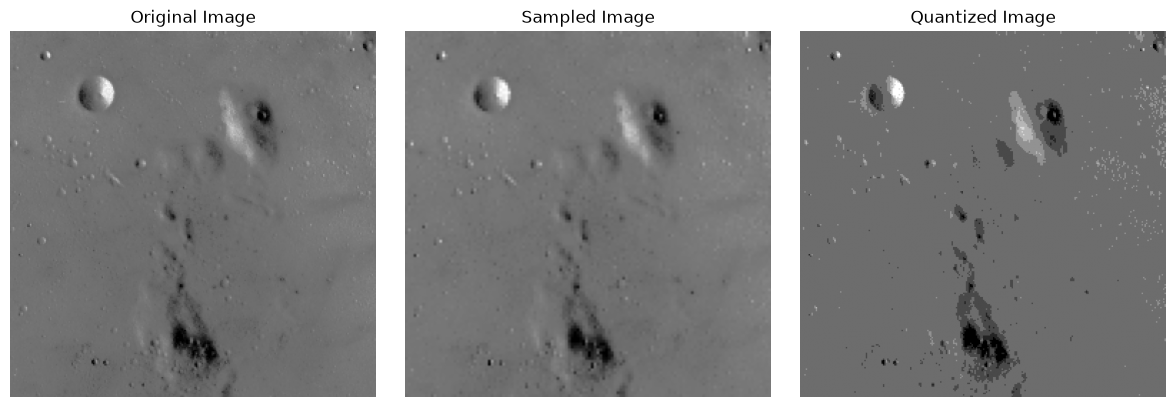

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image, 
        (width // factor, height // factor), 
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    return quantized_image.astype(np.uint8)


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()



image_path = 'images/lena_gray_256.tif'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:

    original_image = cv2.imread('../images/lena_gray_256.tif', cv2.IMREAD_GRAYSCALE)

sampling_factor = 4
quantization_levels = 8

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

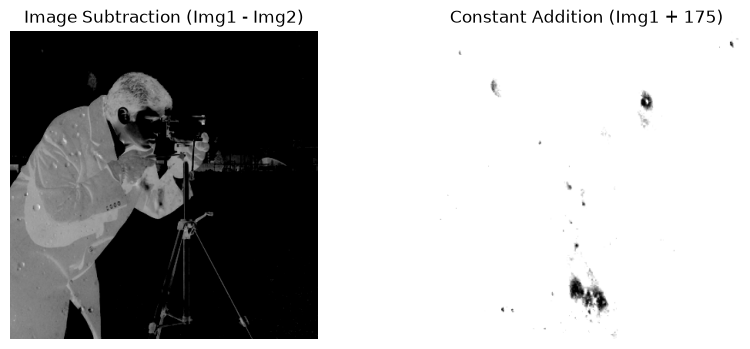

In [2]:
from PIL import Image


img1 = Image.open('images/lena_gray_256.tif').convert('L')
img2 = Image.open('images/cameraman.tif').convert('L')


resize_dims = (400, 400)
img1 = img1.resize(resize_dims, Image.Resampling.LANCZOS)
img2 = img2.resize(resize_dims, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1).astype(np.int16)
im2arr = np.asarray(img2).astype(np.int16)


subtraction = np.clip(im1arr - im2arr, 0, 255).astype(np.uint8)


addition_const = np.clip(im1arr + 175, 0, 255).astype(np.uint8)


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(subtraction, cmap='gray')
plt.title('Image Subtraction (Img1 - Img2)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(addition_const, cmap='gray')
plt.title('Constant Addition (Img1 + 175)')
plt.axis('off')
plt.show()

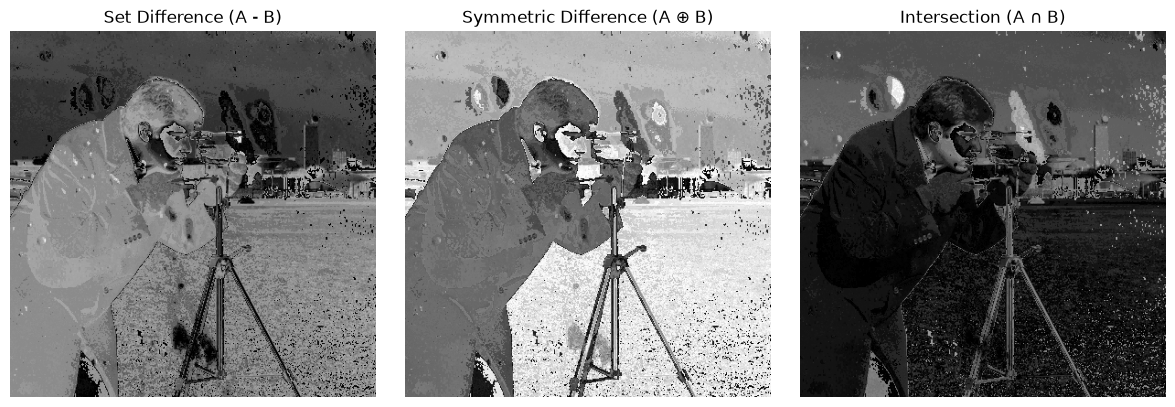

In [3]:
im1_bin = np.asarray(img1)
im2_bin = np.asarray(img2)


set_diff = im1_bin & ~im2_bin


sym_diff = im1_bin ^ im2_bin


intersection = im1_bin & im2_bin


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(set_diff, cmap='gray')
plt.title('Set Difference (A - B)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sym_diff, cmap='gray')
plt.title('Symmetric Difference (A ⊕ B)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(intersection, cmap='gray')
plt.title('Intersection (A ∩ B)')
plt.axis('off')

plt.tight_layout()
plt.show()